# Bankruptcy Prediction and Explainable AI on Ugandan Companies


- Apply the trained bankruptcy prediction model to Ugandan company data.
- Generate bankruptcy predictions.
- Explain model decisions using SHAP.
- Produce business recommendations from the most influential risk factors.


##  Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import shap
import warnings
warnings.filterwarnings('ignore')

##  Load and Prepare Uganda Dataset

Missing numerical values are imputed using the median because financial ratios often contain outliers and skewed distributions.


In [2]:
dfug = pd.read_csv('data/uganda_dataset.csv')
dfug.fillna(dfug.median(numeric_only=True), inplace=True)
dfug.head()

,company,year,bankrupt,Attr27,Attr11,Attr7,Attr34,Attr22,Attr25,Attr13,...,Attr42,Attr6,Attr35,Attr59,Attr30,Attr43,Attr4,Attr48,Attr24,Attr39
0,MTN Uganda Ltd,2024,0,3.993233,0.614978,0.248249,0.262494,0.248249,0.251446,0.970087,...,0.365451,0.251446,0.248249,1.058202,1.047004,10.051567,0.797376,0.354415,0.552810,0.365451
1,MTN Uganda Ltd,2025,0,4.381439,0.614982,0.258867,0.247434,0.258867,0.224681,0.979166,...,0.384861,0.224681,0.258867,1.167532,1.038800,9.163294,0.785988,0.361579,0.555900,0.384861
2,EABL PLC,2024,0,3.037919,0.497748,0.200391,0.269975,0.200391,0.282912,0.498246,...,0.200578,0.135186,0.200391,1.398635,0.610629,102.602085,1.150370,0.266388,0.431785,0.200578
3,EABL PLC,2025,0,4.193753,0.458311,0.192013,0.278684,0.192013,0.310520,0.483283,...,0.195440,0.152163,0.192013,1.064369,0.590542,124.289320,1.110971,0.254297,0.412526,0.195440
4,Equity Group Holdings PLC,2024,0,0.986456,0.100735,0.033658,0.064341,0.033658,0.135752,0.706121,...,0.334129,0.129021,0.033658,0.000000,6.673391,1644.880273,0.747128,0.038175,0.066614,0.334129


##  Explore Class Distribution

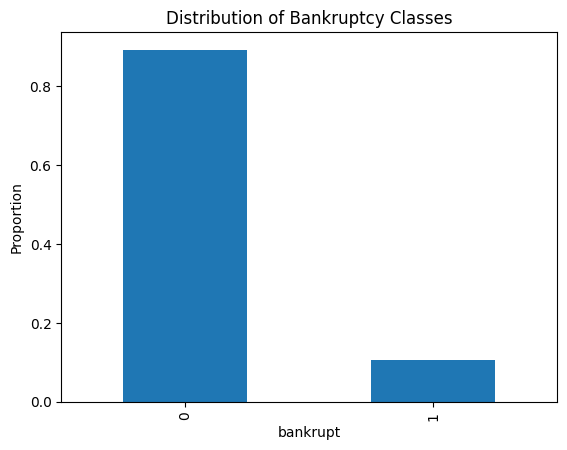

In [3]:
dfug['bankrupt'].value_counts(normalize=True).plot(kind='bar')
plt.title('Distribution of Bankruptcy Classes')
plt.ylabel('Proportion')
plt.show()

##  Prepare Features

The feature order must exactly match the order used during model training.


In [4]:
X_ug = dfug.drop(columns=['company','year','bankrupt'])

correct_order = [
    'Attr11','Attr27','Attr34','Attr26','Attr6','Attr39','Attr7',
    'Attr22','Attr4','Attr21','Attr13','Attr42','Attr48',
    'Attr30','Attr35','Attr25','Attr59','Attr24','Attr43','Attr38'
]

X_ug = X_ug[correct_order]
y_ug = dfug['bankrupt']

##  Load Trained Model and Predict

In [5]:
with open('models/model_xgb.pkl','rb') as f:
    model = pickle.load(f)

predictions = model.predict(X_ug)

dfug['Prediction'] = predictions

dfug[['company','Prediction']].head()

,company,Prediction
0,MTN Uganda Ltd,0
1,MTN Uganda Ltd,0
2,EABL PLC,0
3,EABL PLC,0
4,Equity Group Holdings PLC,0


##  Explainable AI using SHAP

SHAP explains how each feature contributes to model predictions.


In [6]:
explainer = shap.Explainer(model.predict, X_ug)
shap_values = explainer(X_ug)

PermutationExplainer explainer: 29it [00:16,  1.71it/s]                        


### Global Feature Importance 

Features near the top have the greatest influence on predictions.


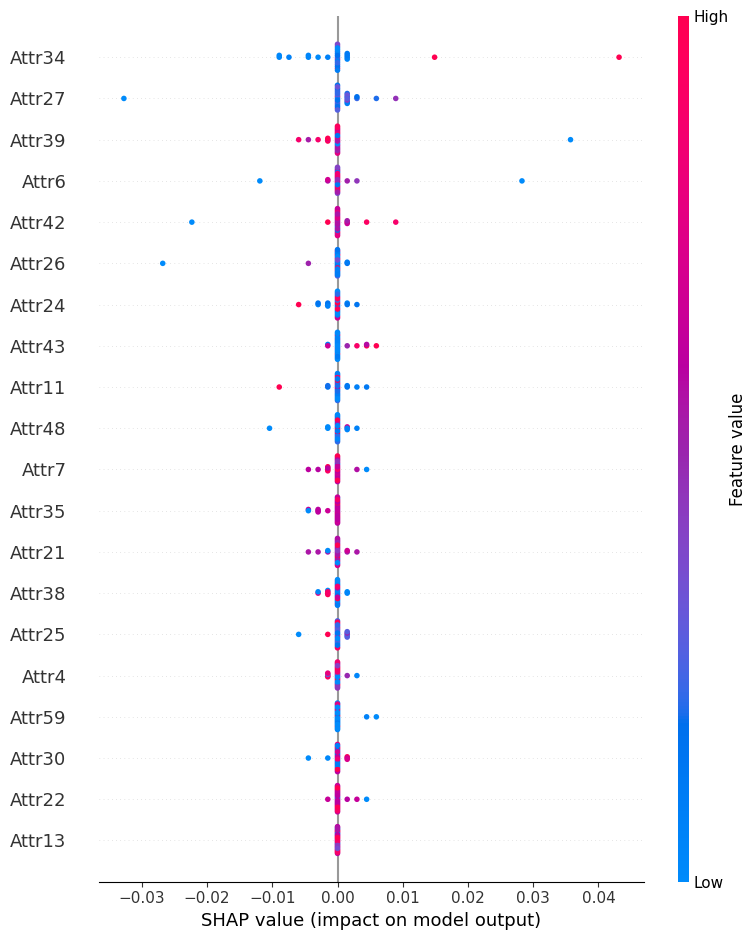

In [7]:
shap.summary_plot(shap_values, X_ug)

### Mean Absolute SHAP Importance

Ranks features by overall contribution magnitude.


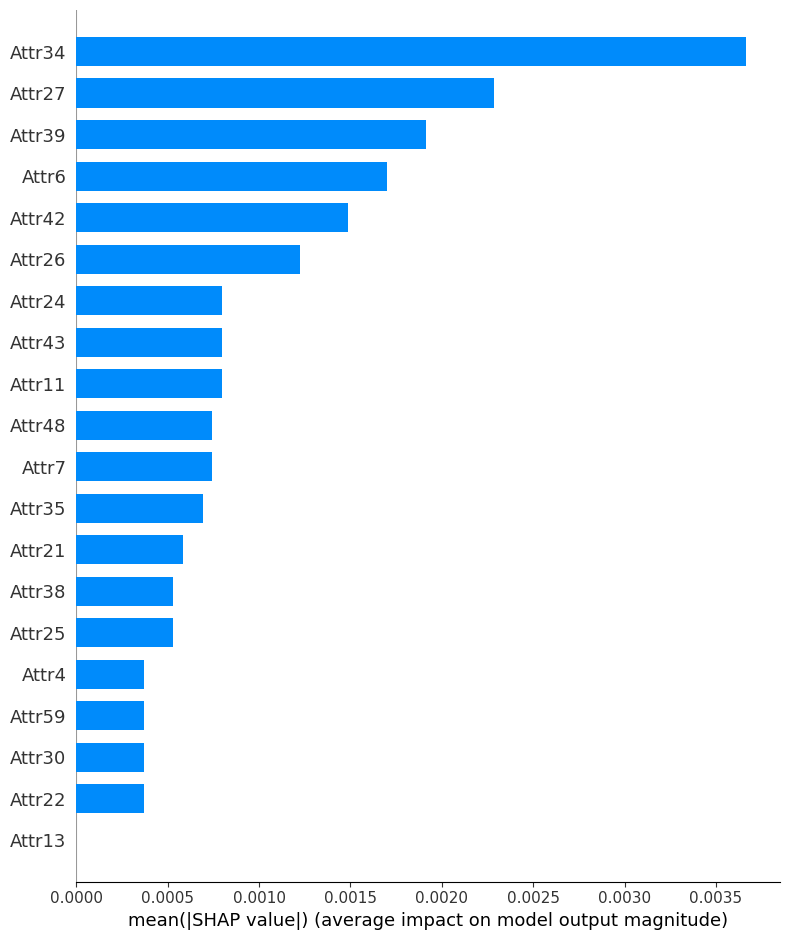

In [8]:
shap.summary_plot(shap_values, X_ug, plot_type='bar')

### SHAP Dependence Plot

Shows how a single feature influences predictions across companies.
Replace Attr39 with the most important feature from your SHAP bar chart if necessary.


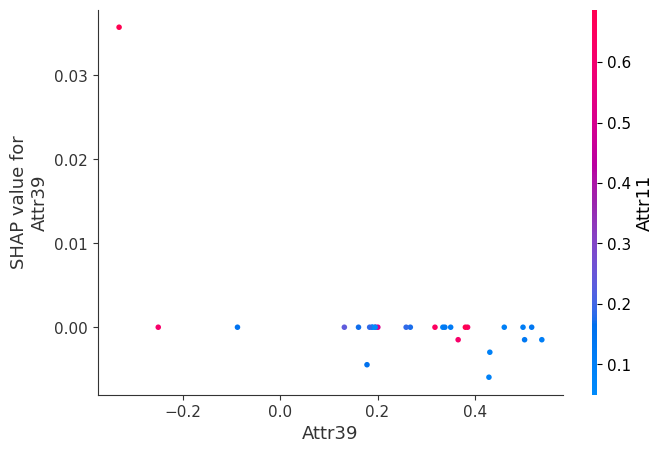

In [9]:
shap.dependence_plot('Attr39', shap_values.values, X_ug)

##  Local Explanation for One Company

In [10]:
sample_index = 0

sample_shap = shap_values[sample_index]

shap_df = pd.DataFrame({
    'Feature': X_ug.columns,
    'Value': X_ug.iloc[sample_index].values,
    'SHAP': sample_shap.values
}).sort_values('SHAP', ascending=False)

shap_df

,Feature,Value,SHAP
15,Attr25,0.251446,0.001488
0,Attr11,0.614978,0.000000
2,Attr34,0.262494,0.000000
1,Attr27,3.993233,0.000000
3,Attr26,0.327423,0.000000
4,Attr6,0.251446,0.000000
7,Attr22,0.248249,0.000000
6,Attr7,0.248249,0.000000
10,Attr13,0.970087,0.000000
9,Attr21,1.105303,0.000000


### Top Positive and Negative Contributors

In [11]:
print('Top Positive Contributors')
print(shap_df.head(5))

print('\nTop Negative Contributors')
print(shap_df.tail(5))

Top Positive Contributors
   Feature     Value      SHAP
15  Attr25  0.251446  0.001488
0   Attr11  0.614978  0.000000
2   Attr34  0.262494  0.000000
1   Attr27  3.993233  0.000000
3   Attr26  0.327423  0.000000

Top Negative Contributors
   Feature      Value      SHAP
14  Attr35   0.248249  0.000000
18  Attr43  10.051567  0.000000
17  Attr24   0.552810  0.000000
19  Attr38   0.527392  0.000000
5   Attr39   0.365451 -0.001488


##  Recommendation Engine

Update the recommendation dictionary to match the final selected features.
Recommendations are generated from the highest positive SHAP contributors.


In [12]:
recommendation_map = {
    'Attr11':'Improve overall profitability and asset utilization.',
    'Attr27':'Reduce financial expenses and debt burden.',
    'Attr34':'Improve operating expense management.',
    'Attr26':'Increase cash-generating ability and solvency.',
    'Attr6':'Strengthen retained earnings.',
    'Attr39':'Improve profit margins.',
    'Attr7':'Increase EBIT relative to assets.',
    'Attr22':'Improve operating profitability.',
    'Attr4':'Improve short-term liquidity.',
    'Attr21':'Increase sales growth.'
}

top_risks = shap_df.head(5)

for feature in top_risks['Feature']:
    if feature in recommendation_map:
        print(f'- {recommendation_map[feature]}')

- Improve overall profitability and asset utilization.
- Improve operating expense management.
- Reduce financial expenses and debt burden.
- Increase cash-generating ability and solvency.


##  Conclusion

The trained bankruptcy model was successfully applied to Ugandan company data.
SHAP was used to provide both global and local explanations, while a recommendation engine translated model insights into actionable business guidance.
